29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)


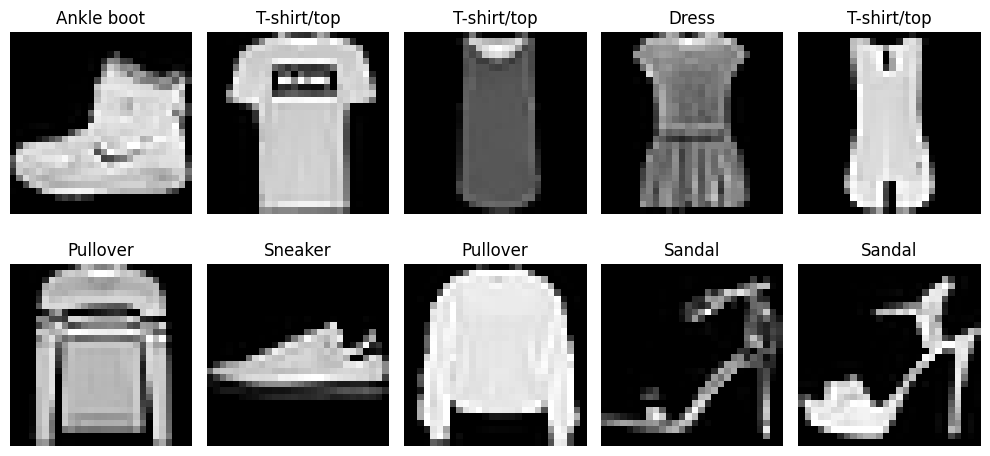

After preprocessing:
Training shape: (60000, 28, 28, 1)
Testing shape : (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.8039 - loss: 0.5456 - val_accuracy: 0.8443 - val_loss: 0.4204
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.8700 - loss: 0.3616 - val_accuracy: 0.8777 - val_loss: 0.3426
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - accuracy: 0.8858 - loss: 0.3151 - val_accuracy: 0.8798 - val_loss: 0.3276
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 74s 56ms/step - accuracy: 0.8994 - loss: 0.2792 - val_accuracy: 0.8943 - val_loss: 0.2855
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9061 - loss: 0.2546 - val_accuracy: 0.8934 - val_loss: 0.2917
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.9132 - loss: 0.2322 - val_accuracy: 0.8985 - val_loss: 0.2877
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9222 - loss: 0.2115 - val_accuracy: 0.9038 - val_loss: 0.2600
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9269 - loss: 0.1981 - 

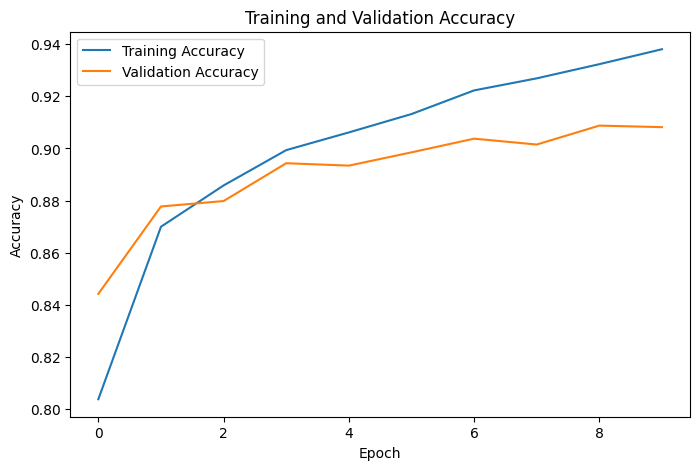

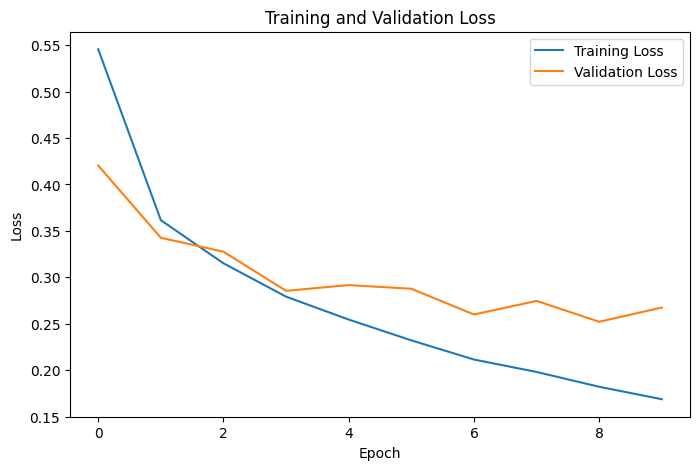

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


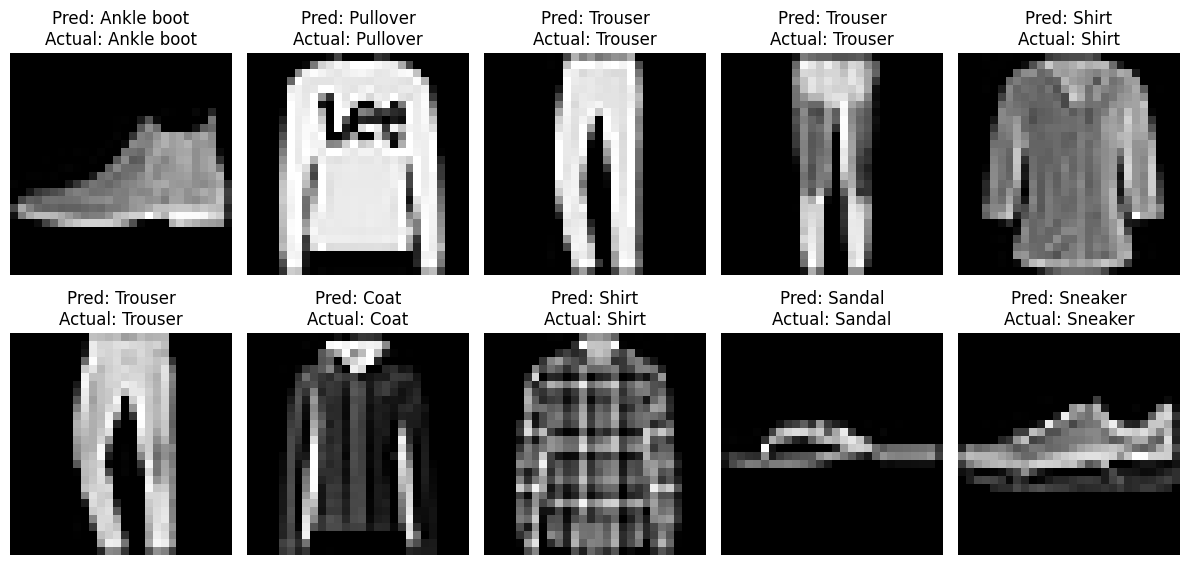

In [ ]:
# ============================================================
# CNN IMAGE CLASSIFICATION USING FASHION-MNIST
# ============================================================

# 1. Import required libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 2. Load Fashion-MNIST Dataset
# ============================================================

(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images :", X_test.shape)


# ============================================================
# 3. Define Class Names
# ============================================================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# ============================================================
# 4. Display Sample Images
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 5. Preprocess the Images
# ============================================================

# Normalize pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension
# 28 x 28  →  28 x 28 x 1
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("After preprocessing:")
print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)


# ============================================================
# 6. Build CNN Model
# ============================================================

model = models.Sequential([

    # Input image: 28 x 28 x 1

    # Convolution Layer 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation="relu"),

    # Output Layer
    # 10 classes → Softmax
    layers.Dense(10, activation="softmax")
])


# ============================================================
# 7. Display Model Architecture
# ============================================================

model.summary()


# ============================================================
# 8. Compile the Model
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 9. Train the CNN
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


# ============================================================
# 10. Evaluate the Model
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=2
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# ============================================================
# 11. Plot Training and Validation Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


# ============================================================
# 12. Plot Training and Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


# ============================================================
# 13. Make Predictions
# ============================================================

predictions = model.predict(X_test)

# Get predicted class
predicted_classes = np.argmax(predictions, axis=1)


# ============================================================
# 14. Display Sample Predictions
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    predicted_label = class_names[predicted_classes[i]]
    actual_label = class_names[y_test[i]]

    plt.title(
        f"Pred: {predicted_label}\nActual: {actual_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()